In Lesson 1, we loaded, cleaned, and concatenated three CSV files into a single tidy dataset, and computed our first descriptive statistics. We saw a hint of right skew — the mean was higher than the median


But we could not see the distribution shape. We could not see where the outliers were. We could not see whether the relationship between property size and price was linear, curved, or noisy. We could not see whether location changes that relationship entirely.


**Research Question:** Are property prices in Mexico more influenced by property
size or by location?

By the end of this lesson, you will have built all the visual evidence you need to
form an initial, data-driven hypothesis before the formal correlation analysis in
Lesson 3.

**By the end of this notebook you will be able to:**

- Explain the difference between **Matplotlib's explicit (object-oriented) and
  implicit (pyplot) interfaces** and choose the explicit interface for all
  professional plotting
- Build and interpret **histograms** to see distribution shape, detect skewness,
  and reason about what the tail of a distribution implies
- Build and interpret **boxplots** (box-and-whisker plots) including all five
  summary statistics: minimum, Q1, median, Q3, maximum, and flagged outlier dots
- Build **scatterplots** to visualize the relationship between two numerical
  variables and identify patterns, noise, and compression from outliers
- Apply **quantile-based outlier removal** to strip extreme values from both
  axes before visual analysis
- Add a **regression trendline** using `seaborn.regplot()` and interpret the
  confidence band width alongside the slope
- Use **`.groupby()`** as the split-apply-combine engine for computing
  per-group statistics and producing grouped visualizations
- Create **small multiples** — a grid of plots, one per category — to compare
  how relationships differ across locations

## 1. Setup and Data Loading

First, let's import our libraries and load the clean dataset we created
in Lesson 1: `"./data/mexico-real-estate-combined-clean.csv"`.

**Code Task 1.2.1.1**

In [1]:
import pandas as pd

# Define the path to the clean CSV file saved in Notebook 1
data_path = "data/mexico-real-estate-combined-clean.csv"
# Load the data
df = pd.read_csv(data_path)

# Verify the load
print(f"Dimensions: {df.shape[0]} rows and {df.shape[1]} columns.")
df.info()
df.head()

Dimensions: 1736 rows and 6 columns.
<class 'pandas.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  1736 non-null   str    
 1   state          1736 non-null   str    
 2   lat            1736 non-null   float64
 3   lon            1736 non-null   float64
 4   area_m2        1736 non-null   float64
 5   price_usd      1736 non-null   float64
dtypes: float64(4), str(2)
memory usage: 112.8 KB


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


> 📊 **After loading — verify the data is intact**
>
> Confirm that `.info()` shows:
> - Six columns: `property_type`, `state`, `lat`, `lon`, `area_m2`, `price_usd`
> - `price_usd` dtype is `float64` (not `object`) — confirming the L1 cleaning succeeded
> - Zero non-null gaps — all 1,700+ rows are complete
>
> If `price_usd` shows `object` here, the file was not saved correctly in L1. Go
> back and re-run L1's `df.to_csv(...)` cell, then reload here.

### The Plotting Library: Matplotlib

#### What is Matplotlib?

Matplotlib is the main plotting library in Python. It is used to create
charts and graphs such as histograms, line charts, scatter plots, and
bar charts.

Many other Python visualization libraries, including Seaborn and Pandas
plotting, use Matplotlib underneath.

The two most important Matplotlib concepts are:

- **Figure** — the complete canvas that contains the visualization.
- **Axes** — the actual area where the chart is drawn.

---

### The Two Matplotlib Interfaces

Matplotlib provides two ways to create plots:

1. **Implicit Interface (Pyplot style)**
2. **Explicit Interface (Object-Oriented style)**

For professional and reusable code, the **Explicit Interface** is recommended.

| | Implicit (Pyplot) | Explicit (Object-Oriented) |
|---|---|---|
| **Example** | `plt.plot(...)` | `fig, ax = plt.subplots()` |
| **Control** | Uses the current plot automatically | You control specific Figure and Axes objects |
| **Multiple plots** | Can become confusing | Easy to manage |
| **Seaborn/Pandas** | Limited control | Easy with `ax=ax` |
| **Recommended** | Quick/simple plots | Professional and reusable code |



> ✅ **Always use the explicit (object-oriented) interface in this course and in
> professional work.**
>
> The implicit interface looks shorter for simple cases, but breaks down as soon
> as you add a second plot, pass axes to Seaborn, or write reusable code. The
> explicit interface has no such limitations.


---

### The Explicit Interface

The standard pattern is:
```python
# Step 1: Create the canvas and the plot area
fig, ax = plt.subplots()

# Step 2: Draw on the specific axes object
ax.hist(df["price_usd"])       # or ax.scatter(), ax.plot(), ax.boxplot()

# Step 3: Label and customize using ax.set_* methods
ax.set_title("My Title")
ax.set_xlabel("X Axis Label")
ax.set_ylabel("Y Axis Label")
ax.set_xlim(0, 500000)         # Optional: fix axis range

# Step 4: Display
plt.tight_layout()  # Prevent labels from being cut off
plt.show()          # Render the figure
```


### 2.1 Histograms

> 🎯 **What is a histogram, and what does it show?**
>
> A histogram shows the **distribution of a numerical variable**. It divides
> values into **bins** (equal-width ranges) and counts how many observations
> fall into each bin. The bars touch because the data is continuous.
>
> **What a histogram reveals:**
> - **Central tendency** — where most values cluster
> - **Spread** — how widely values are distributed
> - **Skewness** — whether values have a longer tail on one side
> - **Modality** — whether there is one or multiple peaks
> - **Outliers** — values far from the main distribution
>
> **Bins** control the number of bars. Too few bins can hide important details,
> while too many can make the plot noisy. Start with the default and adjust
> when necessary.

---

✅ You can take **Multiple Choice Question 1.2.2.1** & **Multiple Choice Question 1.2.2.2**

---

**Code 1.2.2.1** — Histogram of `price_usd`:

### Bar Chart vs Histogram

| Feature | Bar Chart | Histogram |
|---|---|---|
| **Purpose** | Compares categories | Shows numerical data distribution |
| **Data** | Categorical | Numerical |
| **Bars** | Usually have gaps | Bars touch |
| **X-axis** | Categories | Numerical ranges (bins) |
| **Order** | Categories can be reordered | Bins follow numerical order |
| **Example** | Sales by product | Distribution of property prices |

> 📌 **Easy rule:**  
> **Bar chart = compare categories**  
> **Histogram = understand the distribution of numbers**

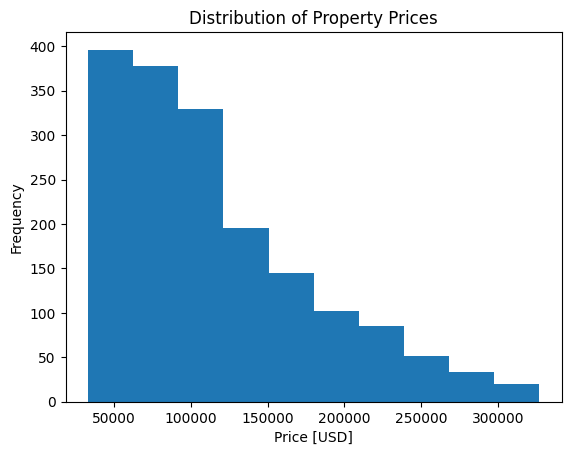

In [2]:

# import matplotlib
import matplotlib.pyplot as plt

# Create a histogram for price
fig, ax = plt.subplots()

# Create a histogram for price_usd
ax.hist(df["price_usd"])

# Add x-axis label, y-axis label & title
ax.set_xlabel("Price [USD]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Prices"); # The semi-colon is added to suppress some ugly text and just gives us the graphic.



> 📊 **Reading the `price_usd` histogram — right-skewed housing prices**
>
> **Shape:** The distribution is **right-skewed (positively skewed)**. Most
> properties are concentrated at lower prices, while a smaller number of
> expensive properties create a long tail to the right.
>
> **Why does this happen?** Housing prices have a lower limit, but there is
> much more room for very expensive properties. As a result, a few high-priced
> properties can pull the **mean above the median**.
>
> **Mean vs. median:**
> - **Median** — represents the middle value and is less affected by extreme prices.
> - **Mean** — is pulled upward by very expensive properties.
>
> **Practical implication:** For strongly right-skewed housing prices, the
> **median is often a better measure of a typical property price** than the mean.

### When Does Right Skew Matter?

**1. Measure of center**

The median is more reliable than the mean when extreme values are present.

**2. Outliers**

Very expensive properties can strongly affect statistical models, especially
models based on squared errors.

**3. Log transformation**

Right-skewed prices can sometimes be transformed using:

```python
np.log(df["price_usd"])

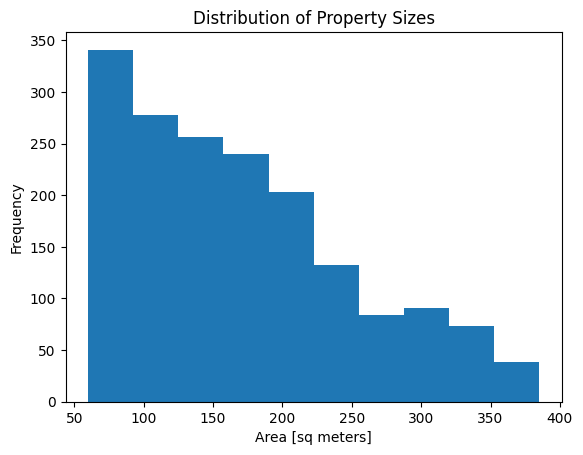

In [3]:
# Create a histogram for area_m2
fig, ax = plt.subplots()

# Use Matplotlib to create histogram of "area_m2"
ax.hist(df["area_m2"])

# Add x-axis label, y-axis label & title
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Sizes");

> 📊 **Reading the `area_m2` histogram — property size distribution**
>
> **Shape:** The distribution is **right-skewed**. Most properties are relatively
> small, while a smaller number of large properties create a long right tail.
>
> **Comparing the two histograms:**
>
> | Variable | Typical Range | Right Tail | Implication |
> |---|---|---|---|
> | `price_usd` | ~60,000–100,000 | Higher-priced properties | Luxury properties can increase the mean |
> | `area_m2` | ~50–150 m² | Much larger properties | Large properties can increase the mean |
>
> **Why are both right-skewed?** Both price and area have a lower bound but can
> have much larger values. A small number of extreme observations can therefore
> create a long right tail.
>
> **What does this mean for analysis?**
>
> Extreme values in `area_m2` and `price_usd` can strongly affect correlation
> and scatterplots. Therefore, outliers should be checked and handled before
> performing size-price analysis.
>
> **Key comparison:**
>
> | Feature | `price_usd` | `area_m2` |
> |---|---|---|
> | Distribution | Right-skewed | Right-skewed |
> | Typical value | Near the median | Near the median |
> | Main cause | Expensive properties | Very large properties |
> | Analytical concern | Extreme prices | Extreme sizes |
>
> 📌 **Key takeaway:** Both variables contain extreme values, so always inspect
> their distributions before using them in statistical analysis.

---

## 3. Bivariate Analysis: Categorical vs. Numerical

Bivariate analysis examines the **relationship between two variables**.

Here, we compare:

- **Numerical variable:** `price_usd`
- **Categorical variables:** `property_type` and `state`

A **boxplot** is useful for comparing the distribution of a numerical variable
across different categories.

> 📌 **Key idea:** Use a boxplot to compare how property prices vary across
> different property types or states.

### Boxplots: Five Numbers in One Chart

> ❓ **Why use a boxplot when you already have a histogram?**
>
> A histogram shows the full shape of one variable's distribution. A boxplot
> compresses that same distribution into five summary numbers — making it ideal
> for *comparing multiple groups side by side*. A histogram of 20 states would
> be unreadable; twenty boxplots in a row are perfectly clear.

**Formal definition: the five-number summary**

A boxplot is a visual representation of the **five-number summary**:

> 📌 **Anatomy of a boxplot**
>
> ```
>     |          ┌────────┬────────┐          |   •  •
>     ───────────┤        │        ├──────────────
>     |          └────────┴────────┘          |
>     ↑          ↑        ↑        ↑          ↑   ↑
>    Min        Q1      Median    Q3         Max Outliers
>  (or fence)                             (or fence)
> ```
>
> | Element | What it is | Statistical name |
> |---|---|---|
> | Left edge of box | 25th percentile — 25% of observations are below this | Q1 (first quartile) |
> | Line inside box | 50th percentile — the middle value | Q2 (median) |
> | Right edge of box | 75th percentile — 75% of observations are below this | Q3 (third quartile) |
> | Box width | Q3 − Q1 = the range of the middle 50% of observations | IQR (Interquartile Range) |
> | Left whisker | Extends to the smallest value within 1.5 × IQR of Q1 | Lower fence |
> | Right whisker | Extends to the largest value within 1.5 × IQR of Q3 | Upper fence |
> | Individual dots beyond whiskers | Observations outside the fences — statistical outliers | Outliers |


### How to Read a Boxplot

- **Box size (IQR):** A wide box indicates greater variability in the middle
  50% of values. A narrow box indicates values are more closely clustered.
- **Median position:** The median near the center suggests a more balanced
  distribution. A median closer to Q1 can indicate right skew.
- **Whisker lengths:** Unequal whiskers can indicate an asymmetric distribution.
  A longer right whisker suggests greater spread toward higher values.
- **Outliers:** Individual points beyond the whiskers represent potential
  outliers. In housing data, these may be unusually expensive properties.

> ⚠️ **What a boxplot does not show:** A boxplot summarizes the data and does
> not show the detailed shape of the distribution. For distribution shape,
> use a **histogram**. For comparing groups, a **boxplot** is often more useful.

---
### 3.1 Comparing Property Types

**Code Task 1.2.3.1:** Create a horizontal boxplot showing `"price_usd"` for
each `"property_type"`.

Requirements:

- X-axis label: `"Price [USD]"`
- Title: `"Price Distribution by Property Type"`
- Use a horizontal boxplot.

> 💡 **Why horizontal?** A horizontal boxplot places the numerical variable
> (`price_usd`) on the x-axis, making price values easier to compare. It is
> especially useful when category names are long.

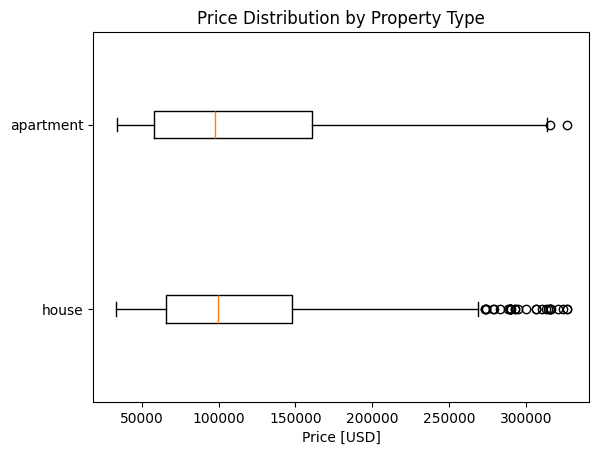

In [6]:
# 1. Get the unique category names on the column "property_type"
prop_types = df["property_type"].unique()

# 2. Prepare the data: Create a list of price arrays, one for each type
data_by_type = [df[df["property_type"] == label]["price_usd"] for label in prop_types]

# 3. Plot
fig, ax = plt.subplots()

# Pass the data list and the labels list
ax.boxplot(data_by_type, tick_labels=prop_types, vert=False)

ax.set_title("Price Distribution by Property Type")
ax.set_xlabel("Price [USD]")


plt.show() # plt.show() acts as the semi-colon, to suppress some ugly text and just give us the graphic.

> 📊 **Reading the property-type boxplot — what the five-number summary reveals**
>
> Apply the anatomy from above:
>
> **Houses (bottom box):**
> - Median line sits around $95,000–$100,000 — the typical house price.
> - Box is relatively narrow — the middle 50% of house prices are tightly clustered.
> - But notice the **long string of outlier dots on the right** — a large number of
>   expensive houses extending well past the upper fence. These are the luxury
>   single-family homes that drive the right skew we saw in the histogram.
>
> **Apartments (top box):**
> - Median line is similar — roughly $95,000–$100,000 — confirming that the
>   *typical* price for both property types is similar.
> - The whiskers are shorter and the outlier tail is smaller — apartments have a
>   more contained price distribution.
>
> **Key insight:** The similar medians might lead you to conclude that property
> type does not affect price. **But this is misleading.** Houses and apartments
> have similar *total* prices, but apartments are smaller. In Lesson 4 we will
> compute `price_per_m2` — price per square meter — and the story changes
> dramatically: apartments are significantly more valuable per unit area.

### How to Read a Boxplot — Checklist

Use this checklist whenever you analyze a boxplot:

- **Step 1 — Find the median:** The line inside the box represents the
  50th percentile. Compare medians across groups first.

- **Step 2 — Check the IQR:** The box represents the middle 50% of the data.
  A wider box means greater variability.

- **Step 3 — Check the median position:** A median near the center suggests
  a balanced distribution. A median closer to Q1 may indicate right skew,
  while one closer to Q3 may indicate left skew.

- **Step 4 — Compare whiskers:** Unequal whisker lengths can indicate
  asymmetry. A longer right whisker suggests greater spread toward higher values.

- **Step 5 — Check outliers:** Dots beyond the whiskers are potential
  outliers. A large number of outliers may indicate a heavy tail or values
  that require further investigation.

> 📌 **Quick rule:** Compare **median → IQR → whiskers → outliers**.

---

✅ You can take **Multiple Choice Question 1.2.3.1**

---

### 3.2 Comparing States

**Code Task 1.2.3.2**: Create a similar horizontal boxplot of `"price_usd"` by
selected major states. Use the top 3 states by listing count.


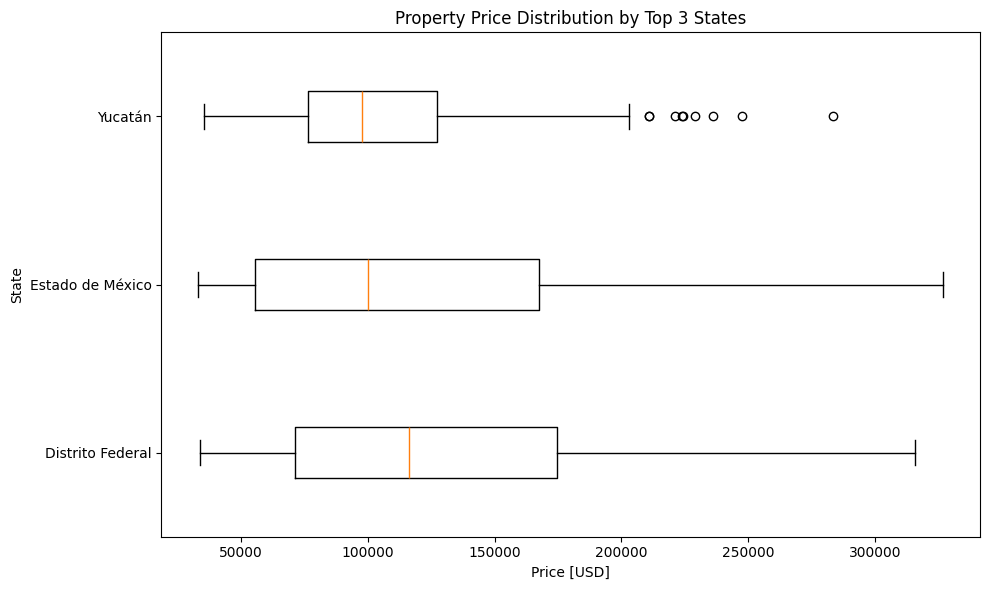

In [27]:
# 1. Define your selected states
selected_states = (
    df["state"]
    .value_counts()
    .head(3)
    .index
    .tolist()
)

# 2. Prepare the data
data_by_state = [
    df[df["state"] == state]["price_usd"]
    for state in selected_states
]

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(
    data_by_state,
    tick_labels=selected_states,
    vert=False
)

ax.set_title("Property Price Distribution by Top 3 States")
ax.set_xlabel("Price [USD]")
ax.set_ylabel("State")

plt.tight_layout()
plt.show()

> 📊 **Reading the States Boxplot — Location and Price**
>
> The boxplot helps compare property prices across the three states.
>
> **Distrito Federal:**
> - Highest median price.
> - Widest box, indicating greater price variability.
> - Several high-priced outliers.
>
> **Estado de México:**
> - Lower median than Distrito Federal.
> - Moderate price variability.
> - Higher-priced properties extend the upper range.
>
> **Yucatán:**
> - Lower median price.
> - Narrower box, indicating more consistent prices.
> - Several high-priced outliers.
>
> **What this bivariate visualization proves:**
> Even without any formal statistics, the boxplot shows that **location matters**.
> Two properties with the same square footage — one in Distrito Federal, one in
> Yucatán — would likely sell at very different prices. This is the "location
> effect" we will quantify in Lesson 4.
>
> 
> **Key takeaway:** Property prices vary considerably by location. This suggests
> that **state is an important factor in housing prices** and can be examined
> further using statistical analysis.

---
## 4. Bivariate Analysis: Numerical vs. Numerical

The main research question is whether **property size (`area_m2`) is related to
price (`price_usd`)**.

### 4.1 Scatterplots

> 🎯 **What a Scatterplot Shows**
>
> A scatterplot shows the relationship between **two numerical variables**.
> Each point represents one property listing.
>
> - **X-axis:** Property area (`area_m2`)
> - **Y-axis:** Property price (`price_usd`)
>
> **What to look for:**
> - **Direction:** Upward = positive relationship; downward = negative relationship.
> - **Strength:** Closely grouped points = stronger relationship; scattered points
>   = weaker relationship.
> - **Form:** Check whether the relationship is linear or curved.
> - **Outliers:** Look for points far from the main group.
>
> 📌 **Key idea:** A scatterplot helps us visually determine whether larger
> properties tend to have higher prices.
>
> **Code 1.2.4.1** — Scatterplot of `area_m2` vs. `price_usd`:

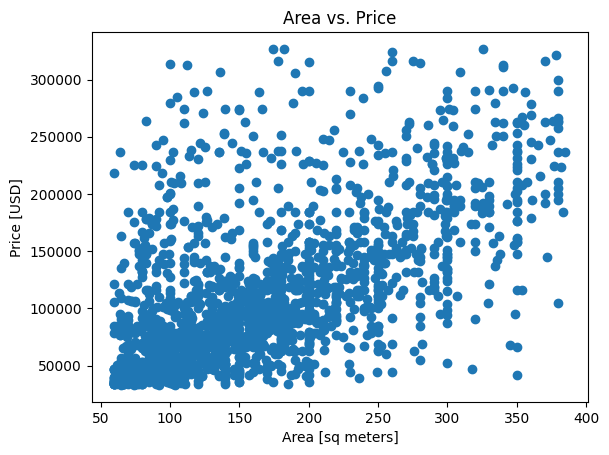

In [28]:
# 1. Create the Figure and Axes objects
fig, ax = plt.subplots()

# 2. Plot on the specific axes object
ax.scatter(x=df["area_m2"], y=df["price_usd"])

# 3. Set labels and title (Note the "set_" prefix)
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price")

plt.show()

> 📊 **Reading the Raw Scatterplot — Effect of Outliers**
>
> The scatterplot may show most points clustered in the lower-left corner, while
> a few extreme properties extend far to the right and upward. These extreme
> values can **compress the main data cluster** and make the relationship difficult
> to see.
>
> **What does compression mean?** A very large property, such as one with
> `area_m2 = 1,000`, forces the x-axis to extend to 1,000. As a result, properties
> below 200 m² may appear crowded together.
>
> **What we cannot clearly determine:**
> - Whether the relationship is linear or curved.
> - How strong the relationship is.
> - Whether the relationship changes across price ranges.
>
> ➡️ **Next step:** We will use quantile-based outlier removal to reduce the
> influence of extreme values and make the main market pattern easier to see.

---
### 4.2 Handling Outliers: Quantile-Based Filtering

> ❓ **Why remove outliers, and why use quantiles?**
>
> **The problem:** A few very large or expensive properties can make the
> scatterplot difficult to read. They can also affect statistical models and
> make the relationship between size and price look different from the typical
> market.
>
> **Why not use a fixed cutoff?** A value like `$250,000` may work for one
> dataset but not another. Quantiles automatically adjust to the data.
>
> For example, the **90th percentile** is the value below which 90% of the
> observations fall. Values above it are the highest 10% of the data.
>
> 📌 **Key idea:** Quantile filtering helps remove extreme values while keeping
> the main part of the dataset for analysis.

---
> 📌 **What is a quantile / percentile?**
>
> The **Nth percentile** of a distribution is the value below which N% of
> observations fall:
>
> | Percentile | Also called | Meaning |
> |---|---|---|
> | 25th | Q1 (first quartile) | 25% of observations are below this value |
> | 50th | Median / Q2 | 50% are below — the middle value |
> | 75th | Q3 (third quartile) | 75% are below |
> | 90th | — | 90% are below — our upper cutoff |
> | 5th | — | 5% are below — our lower cutoff |
>
> In pandas: `df["price_usd"].quantile(0.90)` returns the value at the 90th
> percentile. `df["price_usd"] < df["price_usd"].quantile(0.90)` creates a boolean
> mask that is `True` for the lower 90% of prices.


### Why Asymmetric Cuts? (Bottom 5%, Top 10%)

We remove the **bottom 5%** and the **top 10%** of values. This is intentional.

> 💡 **Why use different cutoffs?**
>
> In real estate, the upper end often has more extreme values because of
> expensive luxury properties. These can strongly affect the analysis.
>
> - **Bottom 5%:** Helps remove unusually low or possibly incorrect prices.
> - **Top 10%:** Helps reduce the effect of very expensive properties.
>
> 📌 **Key idea:** Use different cutoffs when the two tails of the data are
> different. Always examine the data before choosing the cutoffs.

We apply the upper quantile cut to **both** `price_usd` and `area_m2`:
- A 10,000 m² property is almost certainly a data error.
- Even if it is real, it compresses the entire x-axis, hiding the pattern for the
  other 95% of listings.

**Code 1.2.4.2** — Quantile-based outlier removal:

In [29]:
# Define cutoff percentages
lower_cut = 0.05  # Remove bottom 5%
upper_cut = 0.90  # Keep up to 90th percentile

# Filter the data
df_clean = (
    df[
        (df["price_usd"] > df["price_usd"].quantile(lower_cut)) &
        (df["price_usd"] < df["price_usd"].quantile(upper_cut)) &
        (df["area_m2"] < df["area_m2"].quantile(upper_cut)) # <-- Large area outliers also skew the scatter plot
    ]
)

# Show what changed
print(f"Original: {len(df)} rows")
print(f"Cleaned: {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")


Original: 1736 rows
Cleaned: 1365 rows
Removed: 371 rows


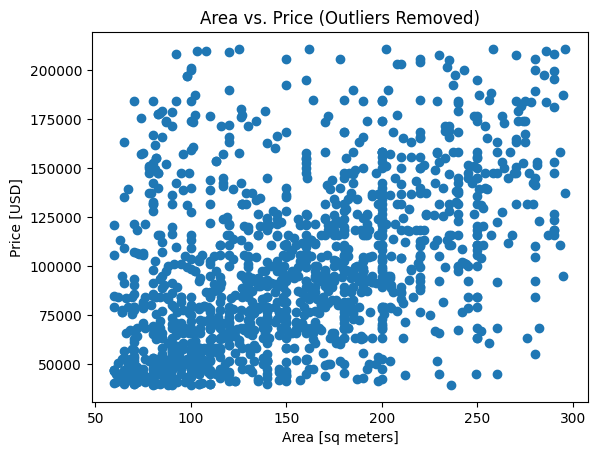

In [30]:

# Plot
fig, ax = plt.subplots()
ax.scatter(df_clean["area_m2"], df_clean["price_usd"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price (Outliers Removed)")
plt.show()

> 📊 **After outlier removal — reading the improved scatterplot**
>
> The scatterplot should now show a cloud of points with a clear upward slope.
> You can actually *see* the relationship:
>
> **What changed:**
> - The x-axis now stops around 200–300 m² (instead of 1,000+ m²).
> - The y-axis now stops around $200,000 (instead of $300,000+).
> - The points fill the plot area rather than clustering in one corner.
>
> **What the cleaned scatterplot reveals:**
> - **Positive relationship:** as area increases, price tends to increase.
> - **Significant scatter:** the cloud is wide, not narrow. At 150 m², prices range
>   from $50,000 to $200,000 — a $150,000 spread. This tells us that area *alone*
>   does not fully explain price. Something else matters (location? property type?).
> - **No obvious curve:** the relationship looks roughly linear in this range, which
>   makes Pearson correlation (Lesson 3) an appropriate measure.
>
> **The three things we accomplished by filtering:**
> 1. **Removed noise** — bottom 5% likely contains data errors (implausibly cheap
>    properties); top 10% are luxury outliers that distort the trend.
> 2. **Revealed the pattern** — the main market cluster is now visible and readable.
> 3. **Prepared for modeling** — any future regression model will learn from the
>    "typical" market rather than being pulled by extreme values.

---

### 4.3 Visualizing the Trend: Seaborn's `regplot`

A scatterplot shows individual points, but it does not show the overall trend.
Seaborn's `sns.regplot()` adds a **regression line** that helps us understand
the general relationship between two numerical variables.

> 💡 **What is Seaborn?**
>
> Seaborn is a Python visualization library built on top of Matplotlib. It
> provides simple and attractive statistical plots, including regression
> plots. It also works with Matplotlib's Figure and Axes objects.
>
> You can use `ax=ax` to draw a Seaborn plot on a specific Matplotlib Axes.

**Code 1.2.4.3** — Trendline using `sns.regplot`:

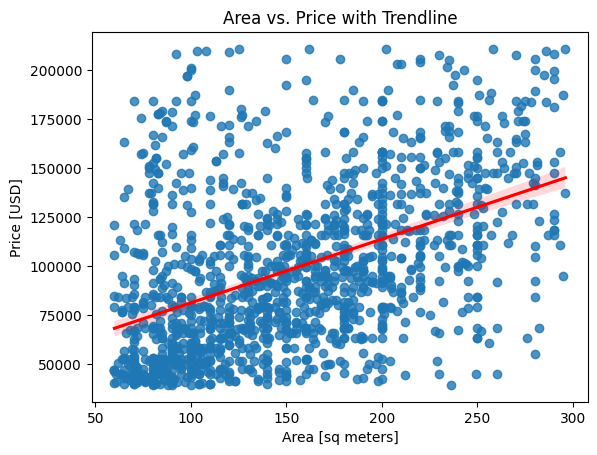

In [32]:
# remember to import your library if you haven't
import seaborn as sns

# Create figure and axis explicitly
fig, ax = plt.subplots()

# Use Seaborn to plot scatter + trendline
sns.regplot(
    data=df_clean, 
    x="area_m2", 
    y="price_usd", 
    line_kws={"color": "red"},  # Make the line distinct
    ax=ax  # Pass the axis to seaborn
)

ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price with Trendline")
plt.show()

> 📊 **Reading the `sns.regplot` Output — Trend and Variation**
>
> **The regression line:**  
> The line slopes upward, showing a **positive relationship** between area and
> price. In general, larger properties tend to have higher prices.
>
> **The shaded band:**  
> The shaded area represents the **95% confidence interval** around the regression
> line. A narrow band means more confidence in the estimated trend, while a wider
> band means more uncertainty.
>
> **Heteroscedasticity:**  
> The points may spread out more as property size increases. This means prices
> become more variable for larger properties. This pattern is called
> **heteroscedasticity**.
>
> 📌 **Key takeaway:** Area is related to price, but the relationship is not
> perfect. Other factors, such as location and property type, also affect price.
>
> **The slope:**  
> The slope represents the average change in price for each additional square
> meter. For example, a slope of `700` means that an additional `1 m²` is
> associated with an average price increase of about `$700`.

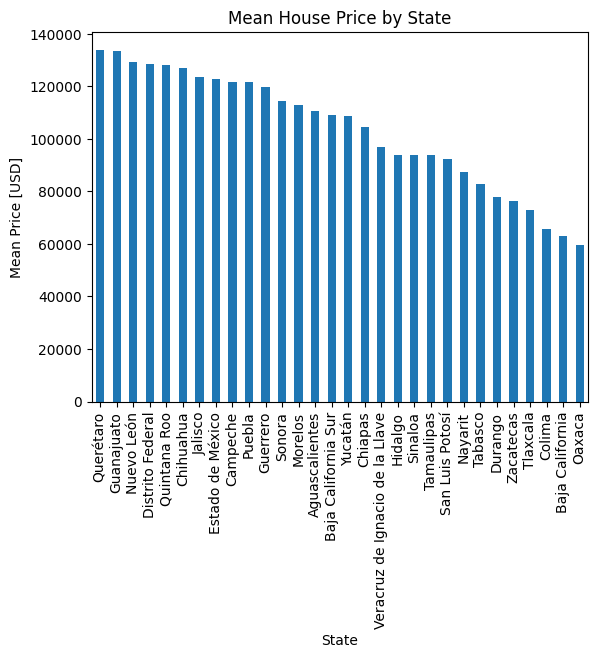

In [33]:
# Aggregate data using groupby
mean_price_by_state = (
    df.groupby("state")["price_usd"]  # <-- "state" & "price_usd"
    .mean()
    .sort_values(ascending=False) # <-- pass in True or False to sort
)

# Create figure and axes explicitly
fig, ax = plt.subplots()

# Use pandas plot method with explicit axes
mean_price_by_state.plot(
    kind="bar",
    ax=ax  # Pass the axes to pandas
)

# Customize using Matplotlib methods
ax.set_xlabel("State")
ax.set_ylabel("Mean Price [USD]")
ax.set_title("Mean House Price by State")

plt.show()

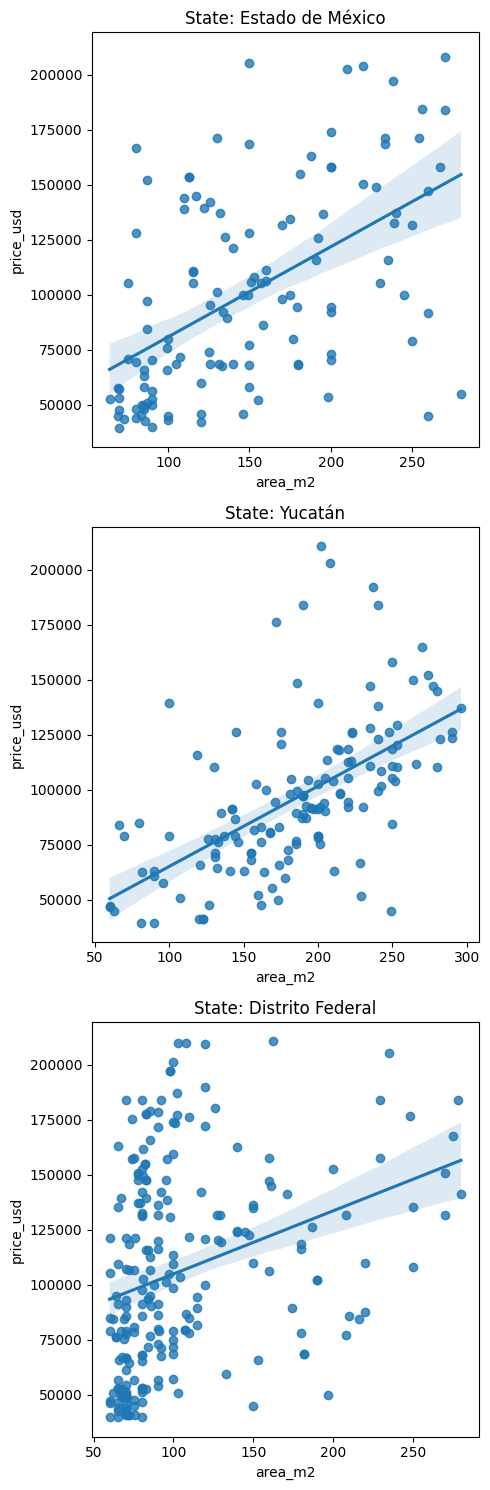

In [34]:
## 1. Create your custom figure and axes
fig, axes = plt.subplots(3, 1, figsize=(5, 15), sharey=True)

# 2. Create a list of the top 3 states
top_states = selected_states  # <--- pass selected_states

# 3. Filter df_clean to include only these states
df_states = df_clean[df_clean["state"].isin(top_states)]

# 4. Loop through the states and plot on each specific axis
states = df_states["state"].unique()

for ax, state in zip(axes, states):
    # Filter data for the current state
    subset = df_states[df_states["state"] == state]
    
    # Use regplot (Axes-level) which ACCEPTS 'ax='
    sns.regplot(
        data=subset,
        x="area_m2",  # <--- "area_m2"
        y="price_usd",  # <--- "price_usd" 
        color='tab:blue', # Optional: keep colors consistent
        ax=ax # <--- This is where you pass the axis explicitly
    )
    
    ax.set_title(f"State: {state}")

plt.tight_layout()
plt.show()

---
**Multiple Choice Question 1.2.2.1**

Which Matplotlib interface is considered the "professional standard" for complex plots because it explicitly creates Figure and Axes objects?

A. The Implicit Interface (Pyplot Style)

B. The Pandas Inline Interface

C. The Seaborn Implicit Interface

D. The Explicit Interface (Object-Oriented Style)

**Correct Answer:** D. The Explicit Interface (Object-Oriented Style)

**Multiple Choice Question 1.2.2.2**

When using the Explicit interface in Matplotlib (the `ax` object), what prefix is required for commands used to label a chart’s title or axes?

A. `ax.show_title`

B. `ax.get_title`

C. `ax.set_title`

D. `ax.put_title`

**Correct Answer:** C. `ax.set_title`

**Multiple Choice Question 1.2.2.3**

What is a key visual difference between a histogram and a bar chart?

A. Histogram bars touch to show that numerical data flows continuously from one range to the next.

B. Histograms can only show 5 different categories at once.

C. Histogram bars never touch each other.

D. Bar charts are only used for the "Interquartile Range."

**Correct Answer:** A. Histogram bars touch to show that numerical data flows continuously from one range to the next.

**Multiple Choice Question 1.2.3.1**

In a box plot, what does the central **box** specifically represent?

A. The mathematical average (mean) of the entire dataset.

B. The middle 50% of the data (the Interquartile Range).

C. Only the properties that are considered extreme outliers.

D. The total range of all data points, including outliers.

**Correct Answer:** B. The middle 50% of the data (the Interquartile Range).

**Multiple Choice Question 1.2.4.1**

Why is it important to remove extreme outliers using quantiles before building a predictive model?

A. To ensure that every state in the data has the exact same average price.

B. To prevent extreme values from strongly influencing the machine learning model.

C. To make the dataset smaller so the computer runs faster.

D. To hide the most expensive houses from the final report.

**Correct Answer:** B. To prevent extreme values from strongly influencing the machine learning model.